In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv


In [3]:
df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (4000, 28)

First 5 rows:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3



Column names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moistur

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

Missing values in each column:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [6]:
numeric_columns_to_fill = [
    'Rainfall_mm',
    'Soil_Moisture_pct',
    'Yield_Tonnes_Ha'
]

for column in numeric_columns_to_fill:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after cleaning:")
print(df.isnull().sum().sum())

Missing values after cleaning:
0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Duplicate rows: 0
Dataset shape after removing duplicates: (4000, 28)


In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [10]:
print(df['Season'].value_counts())

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [11]:
season_performance = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean'
}).round(2)

display(season_performance)

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR
Season,,,,
Kharif,5.63,46.31,710719.06,178914.65
Rabi,5.04,41.49,601526.05,87689.47
Zaid,4.64,38.89,519171.90,-24804.82


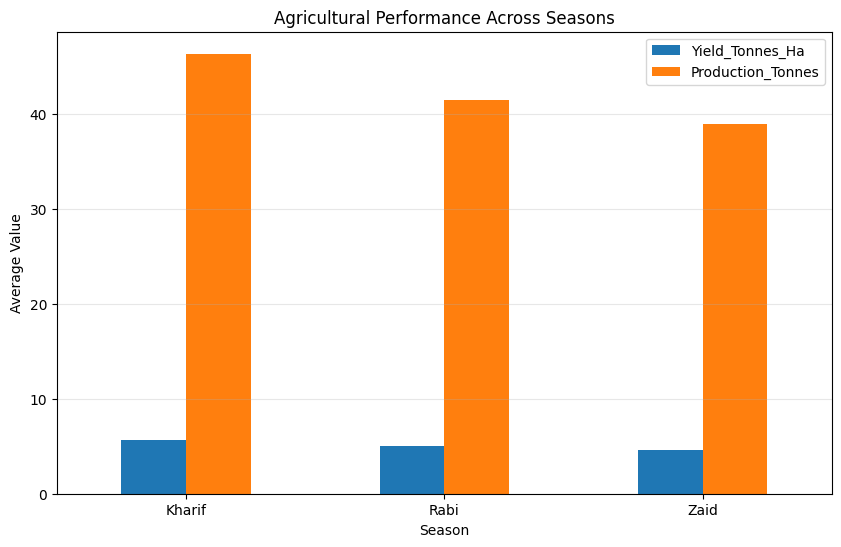

In [12]:
season_performance[['Yield_Tonnes_Ha', 'Production_Tonnes']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Agricultural Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [13]:
environmental = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean'
}).round(2)

display(environmental)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,849.20,28.45,71.81,31.15
Rabi,437.62,23.49,57.89,24.07
Zaid,304.65,31.04,52.01,19.28


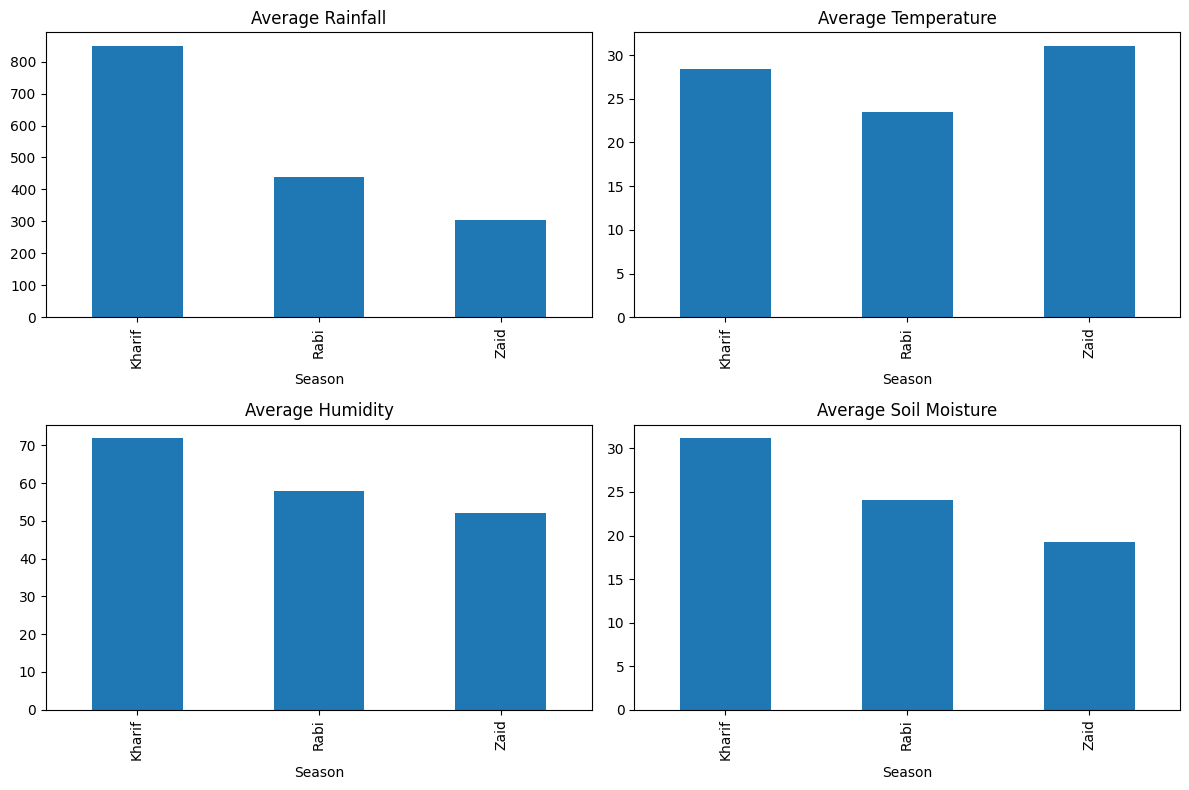

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

season_order = ['Kharif', 'Rabi', 'Zaid']

df.groupby('Season')['Rainfall_mm'].mean().reindex(season_order).plot(
    kind='bar', ax=axes[0,0]
)
axes[0,0].set_title('Average Rainfall')

df.groupby('Season')['Avg_Temperature_C'].mean().reindex(season_order).plot(
    kind='bar', ax=axes[0,1]
)
axes[0,1].set_title('Average Temperature')

df.groupby('Season')['Humidity_pct'].mean().reindex(season_order).plot(
    kind='bar', ax=axes[1,0]
)
axes[1,0].set_title('Average Humidity')

df.groupby('Season')['Soil_Moisture_pct'].mean().reindex(season_order).plot(
    kind='bar', ax=axes[1,1]
)
axes[1,1].set_title('Average Soil Moisture')

plt.tight_layout()
plt.show()

In [15]:
resource_analysis = df.groupby('Season').agg({
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean'
}).round(2)

display(resource_analysis)

,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,
Kharif,187.08,5.08,6102.20,5.89
Rabi,185.41,5.02,5846.99,5.19
Zaid,184.64,5.17,6419.89,4.41


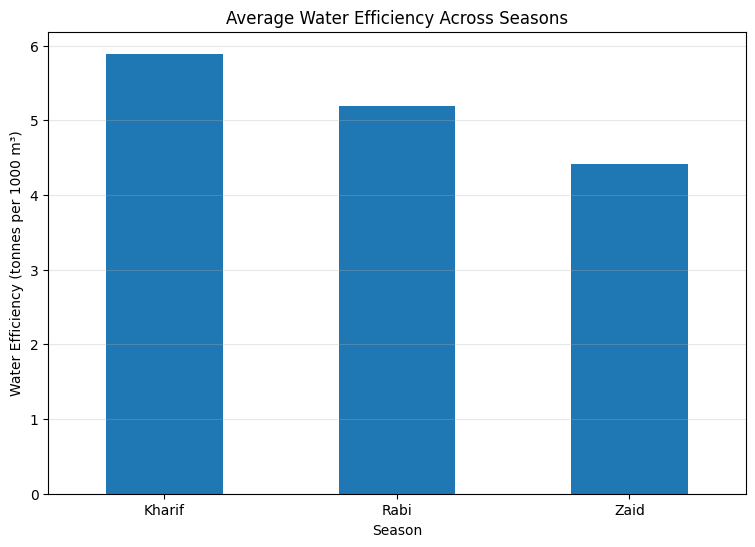

In [16]:
water_efficiency = (
    df.groupby('Season')['Water_Efficiency_t_per_1000m3']
    .mean()
    .reindex(['Kharif', 'Rabi', 'Zaid'])
)

plt.figure(figsize=(9,6))

water_efficiency.plot(kind='bar')

plt.title('Average Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (tonnes per 1000 m³)')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

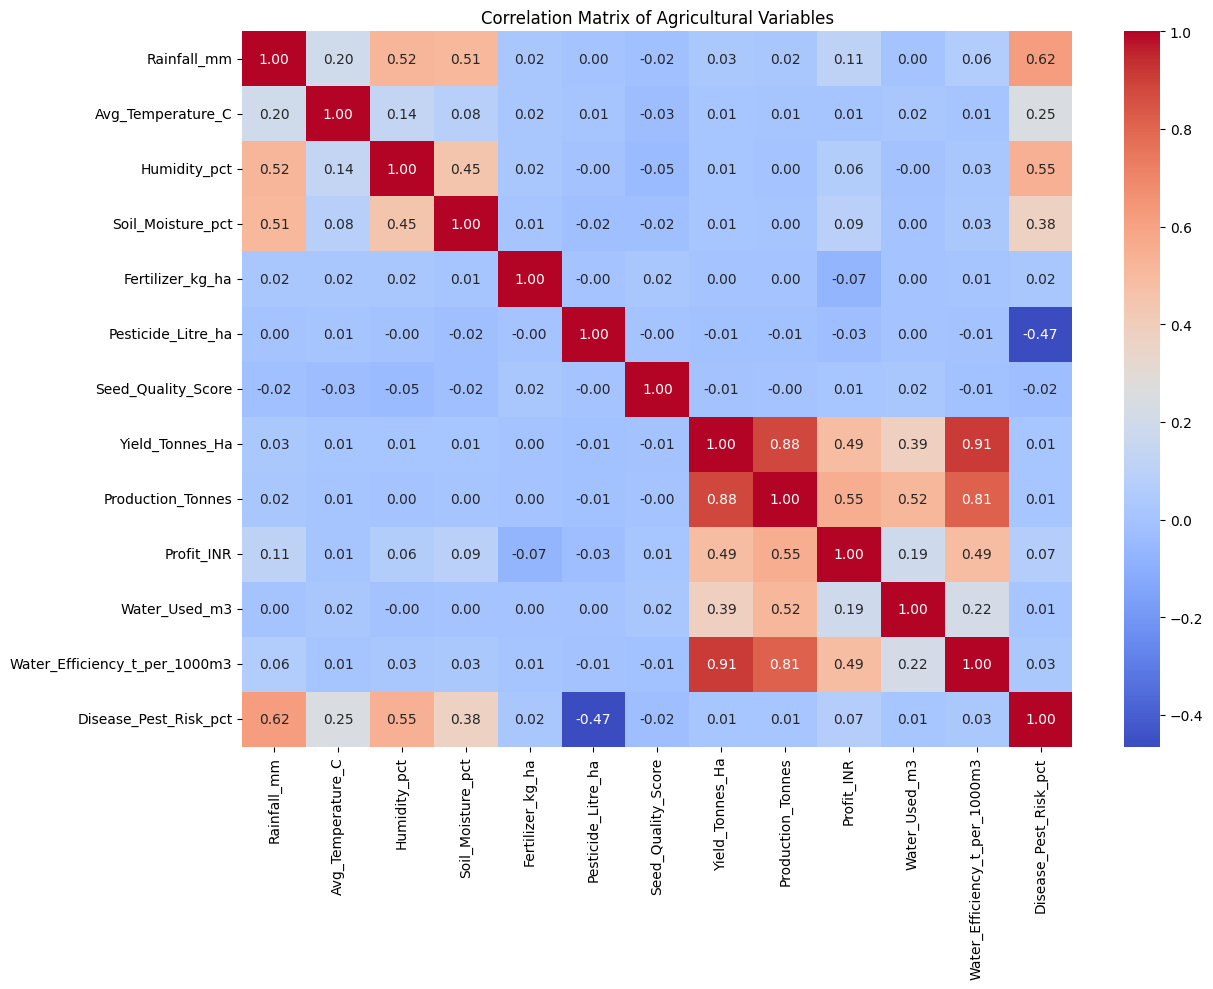

In [17]:
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(13,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Agricultural Variables')
plt.tight_layout()
plt.show()

In [18]:
crop_season = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
).round(2)

display(crop_season)

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


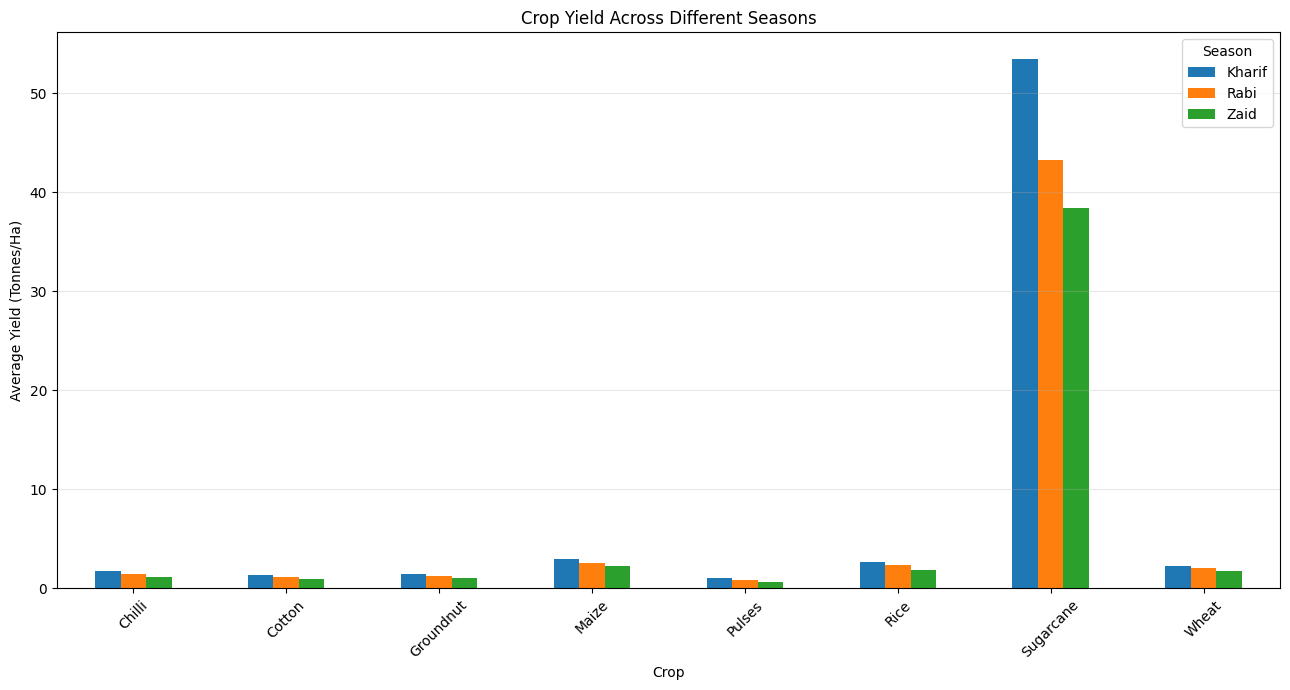

In [19]:
crop_season.plot(
    kind='bar',
    figsize=(13,7)
)

plt.title('Crop Yield Across Different Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=45)
plt.legend(title='Season')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()